In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib
import warnings

warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/job_salary_prediction_dataset.csv")

In [3]:
print(df.head())

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nInfo:")
print(df.info())

            job_title  experience_years education_level  skills_count  \
0         AI Engineer                10        Bachelor             2   
1        Data Analyst                 5        Bachelor            17   
2  Frontend Developer                18             PhD             4   
3    Business Analyst                19             PhD            13   
4     Product Manager                15        Bachelor             7   

        industry company_size   location remote_work  certifications  salary  
0     Healthcare       Medium      India      Hybrid               2  109413  
1        Telecom        Small  Australia          No               0   93764  
2          Media       Medium  Singapore          No               1  148123  
3         Retail       Medium     Canada         Yes               0  189123  
4  Manufacturing        Large     Sweden         Yes               0  165069  

Shape:
(250000, 10)

Columns:
Index(['job_title', 'experience_years', 'education_level

In [4]:
print(df.isnull().sum())

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64


In [5]:
print(df.describe())

       experience_years   skills_count  certifications         salary
count     250000.000000  250000.000000   250000.000000  250000.000000
mean          10.005408       9.997812        2.491928  145718.080524
std            6.060602       5.479288        1.706475   37407.952729
min            0.000000       1.000000        0.000000   31867.000000
25%            5.000000       5.000000        1.000000  119358.000000
50%           10.000000      10.000000        2.000000  143453.000000
75%           15.000000      15.000000        4.000000  169492.000000
max           20.000000      19.000000        5.000000  333046.000000


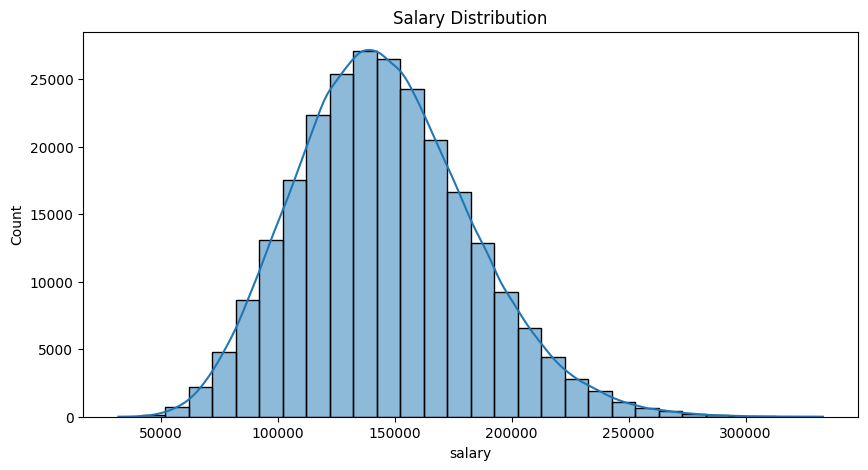

In [6]:
plt.figure(figsize=(10,5))

sns.histplot(df["salary"], bins=30, kde=True)

plt.title("Salary Distribution")

plt.show()

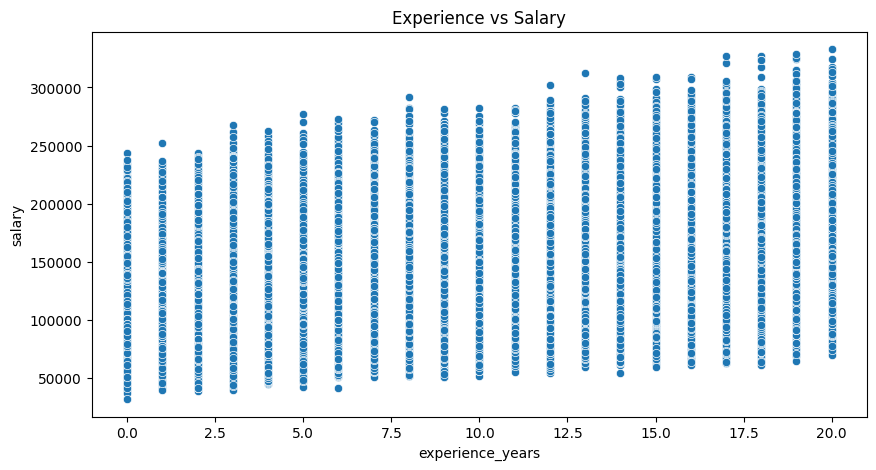

In [7]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    x=df["experience_years"],
    y=df["salary"]
)

plt.title("Experience vs Salary")

plt.show()

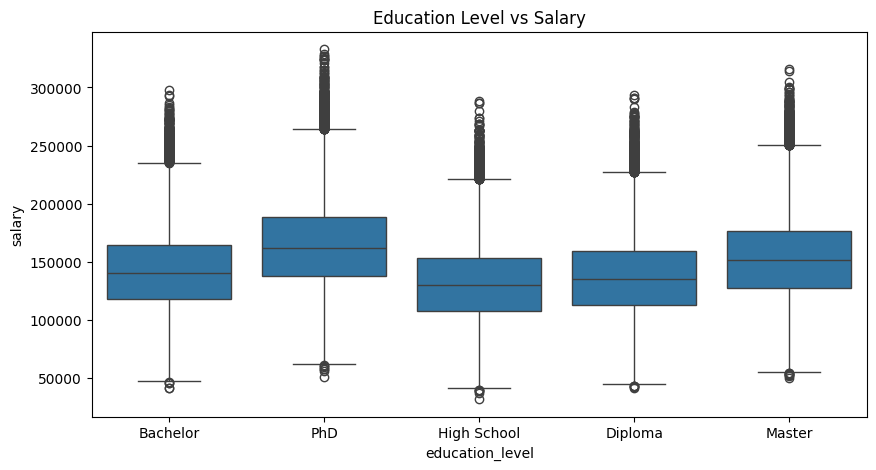

In [8]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df["education_level"],
    y=df["salary"]
)

plt.title("Education Level vs Salary")

plt.show()

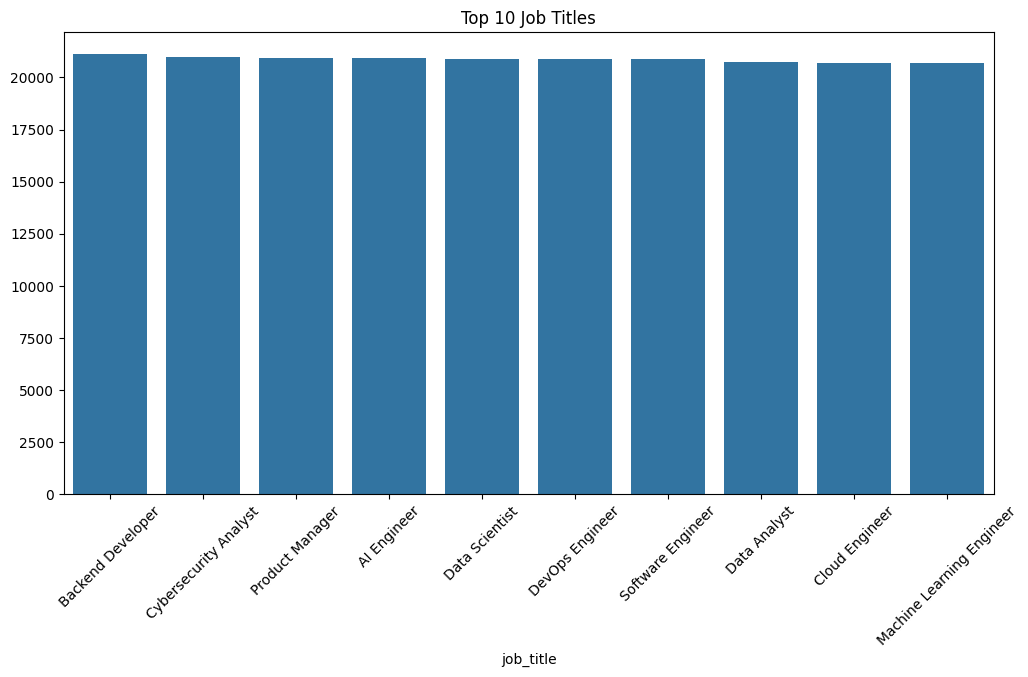

In [9]:
plt.figure(figsize=(12,6))

top_jobs = df["job_title"].value_counts().head(10)

sns.barplot(
    x=top_jobs.index,
    y=top_jobs.values
)

plt.xticks(rotation=45)

plt.title("Top 10 Job Titles")

plt.show()

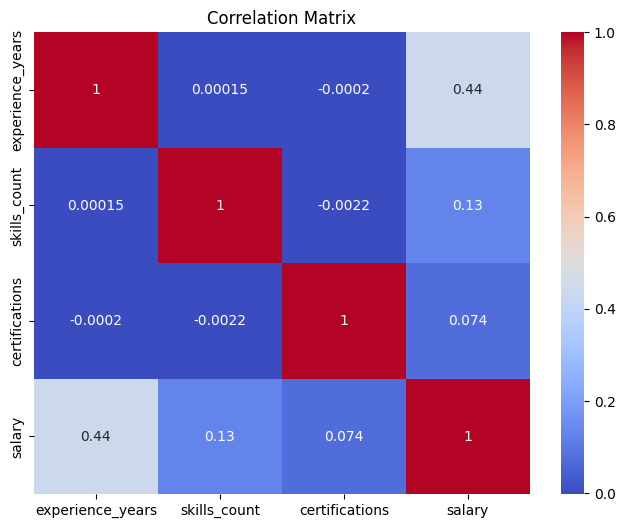

In [10]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [11]:
X = df.drop("salary", axis=1)

y = df["salary"]

In [12]:
categorical_cols = X.select_dtypes(include=["object"]).columns

numerical_cols = X.select_dtypes(exclude=["object"]).columns

print(categorical_cols)

print(numerical_cols)

Index(['job_title', 'education_level', 'industry', 'company_size', 'location',
       'remote_work'],
      dtype='object')
Index(['experience_years', 'skills_count', 'certifications'], dtype='object')


In [13]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
models = {

    "Linear Regression":
        LinearRegression(),

    "Decision Tree":
        DecisionTreeRegressor(
            max_depth=10,
            random_state=42
        ),

    "Random Forest":
        RandomForestRegressor(
            n_estimators=50,
            max_depth=10,
            random_state=42,
            n_jobs=-1
        ),

    "Gradient Boosting":
        GradientBoostingRegressor(
            random_state=42
        )
}

In [16]:
results = []

best_score = -1
best_model = None

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    r2 = r2_score(y_test, y_pred)

    results.append([
        name,
        mae,
        rmse,
        r2
    ])

    print(f"\n{name}")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2:", r2)

    if r2 > best_score:
        best_score = r2
        best_model = pipeline


Linear Regression
MAE: 5436.0969586494775
RMSE: 7125.522920575377
R2: 0.9634690226760201

Decision Tree
MAE: 12907.291154103461
RMSE: 16407.26064782236
R2: 0.8063132271331972

Random Forest
MAE: 12167.888133067478
RMSE: 15463.127743838542
R2: 0.8279627484318679

Gradient Boosting
MAE: 6595.4324061175275
RMSE: 8392.192703306193
R2: 0.9493267564859803


In [17]:
results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2"]
)

results_df

,Model,MAE,RMSE,R2
0,Linear Regression,5436.096959,7125.522921,0.963469
1,Decision Tree,12907.291154,16407.260648,0.806313
2,Random Forest,12167.888133,15463.127744,0.827963
3,Gradient Boosting,6595.432406,8392.192703,0.949327


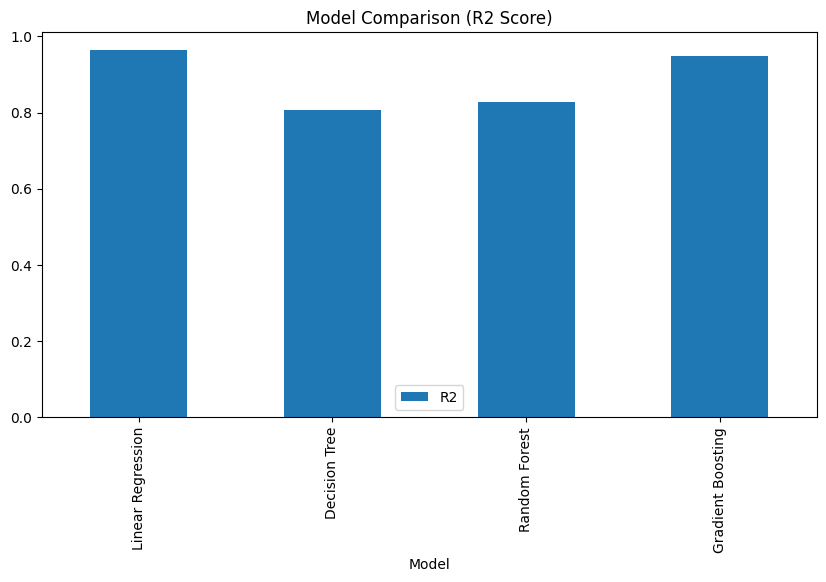

In [18]:
results_df.plot(
    x="Model",
    y="R2",
    kind="bar",
    figsize=(10,5)
)

plt.title("Model Comparison (R2 Score)")

plt.show()

In [19]:
scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Cross Validation Scores:")
print(scores)

print("Average Score:")
print(scores.mean())

Cross Validation Scores:
[0.96368078 0.96332835 0.96325859 0.96338034 0.96319994]
Average Score:
0.9633695979223835


In [20]:
param_grid = {
    "model__n_estimators": [20, 50],
    "model__max_depth": [5, 10]
}

grid = GridSearchCV(
    Pipeline([
        ("preprocessor", preprocessor),
        ("model",
         RandomForestRegressor(random_state=42))
    ]),
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'model__max_depth': 10, 'model__n_estimators': 50}


In [21]:
best_model = grid.best_estimator_

In [22]:
joblib.dump(
    best_model,
    "../models/best_model.pkl"
)

print("Model saved successfully")

Model saved successfully


In [23]:
model = joblib.load("../models/best_model.pkl")

sample = pd.DataFrame({

    'job_title': ['Data Scientist'],
    'experience_years': [5],
    'education_level': ['Master'],
    'skills_count': [10],
    'industry': ['IT'],
    'company_size': ['Large'],
    'location': ['USA'],
    'remote_work': ['Yes'],
    'certifications': [3]
})

prediction = model.predict(sample)

print("Predicted Salary:", prediction[0])

Predicted Salary: 168628.75865894114
